# 03D: Gaussian Mixture Model (GMM) Clustering

## Objective
Cluster stocks with probabilistic assignments using GMM and select components via BIC/AIC.

In [2]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn kagglehub

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import kagglehub

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

Note: you may need to restart the kernel to use updated packages.


In [3]:
cwd = Path.cwd()
TASK_FOLDER = '03_stock_clustering_analysis'
if cwd.name == 'implementation':
    task_root = cwd.parent
elif cwd.name == TASK_FOLDER:
    task_root = cwd
elif (cwd / TASK_FOLDER).exists():
    task_root = cwd / TASK_FOLDER
else:
    task_root = cwd
DATA_DIR = task_root / 'data'
GRAPH_DIR = task_root / 'graph'
DATA_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR.mkdir(parents=True, exist_ok=True)
RAW_CACHE = DATA_DIR / 'sp500_raw.csv'
FEATURE_CACHE = DATA_DIR / 'clustering_features_latest.csv'

In [4]:
def create_clustering_features(stock_data: pd.DataFrame) -> pd.DataFrame:
    stock_data = stock_data.sort_values('date').reset_index(drop=True).copy()
    stock_data['volatility'] = stock_data['close'].pct_change().rolling(20).std()
    stock_data['avg_return'] = stock_data['close'].pct_change().rolling(20).mean()
    stock_data['avg_volume'] = stock_data['volume'].rolling(20).mean()
    stock_data['volume_volatility'] = stock_data['volume'].rolling(20).std() / stock_data['volume'].rolling(20).mean()
    stock_data['momentum'] = (stock_data['close'] - stock_data['close'].shift(20)) / stock_data['close'].shift(20)
    stock_data['price_range'] = (stock_data['high'] - stock_data['low']) / stock_data['close']
    stock_data['trend_strength'] = (stock_data['close'] - stock_data['low']) / (stock_data['high'] - stock_data['low'])
    stock_data['price_level'] = stock_data['close'] / 100
    stock_data['volume_to_price_ratio'] = stock_data['volume'] / stock_data['close']
    return stock_data

def load_raw_data() -> pd.DataFrame:
    if RAW_CACHE.exists():
        return pd.read_csv(RAW_CACHE)
    path = kagglehub.dataset_download('camnugent/sandp500')
    csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
    df = pd.read_csv(os.path.join(path, csv_files[0]))
    df.to_csv(RAW_CACHE, index=False)
    return df

def load_feature_table(data: pd.DataFrame) -> pd.DataFrame:
    if FEATURE_CACHE.exists():
        return pd.read_csv(FEATURE_CACHE)
    processed = pd.concat([create_clustering_features(data[data['Name'] == s]) for s in data['Name'].unique()], ignore_index=True)
    clustering_data = processed.sort_values('date').drop_duplicates('Name', keep='last').dropna().reset_index(drop=True)
    clustering_data.to_csv(FEATURE_CACHE, index=False)
    return clustering_data

data = load_raw_data()
clustering_data = load_feature_table(data)
feature_cols = ['volatility','avg_return','avg_volume','volume_volatility','momentum','price_range','trend_strength','price_level','volume_to_price_ratio']
X = clustering_data[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(clustering_data[feature_cols].median(numeric_only=True))
X_scaled = StandardScaler().fit_transform(X)

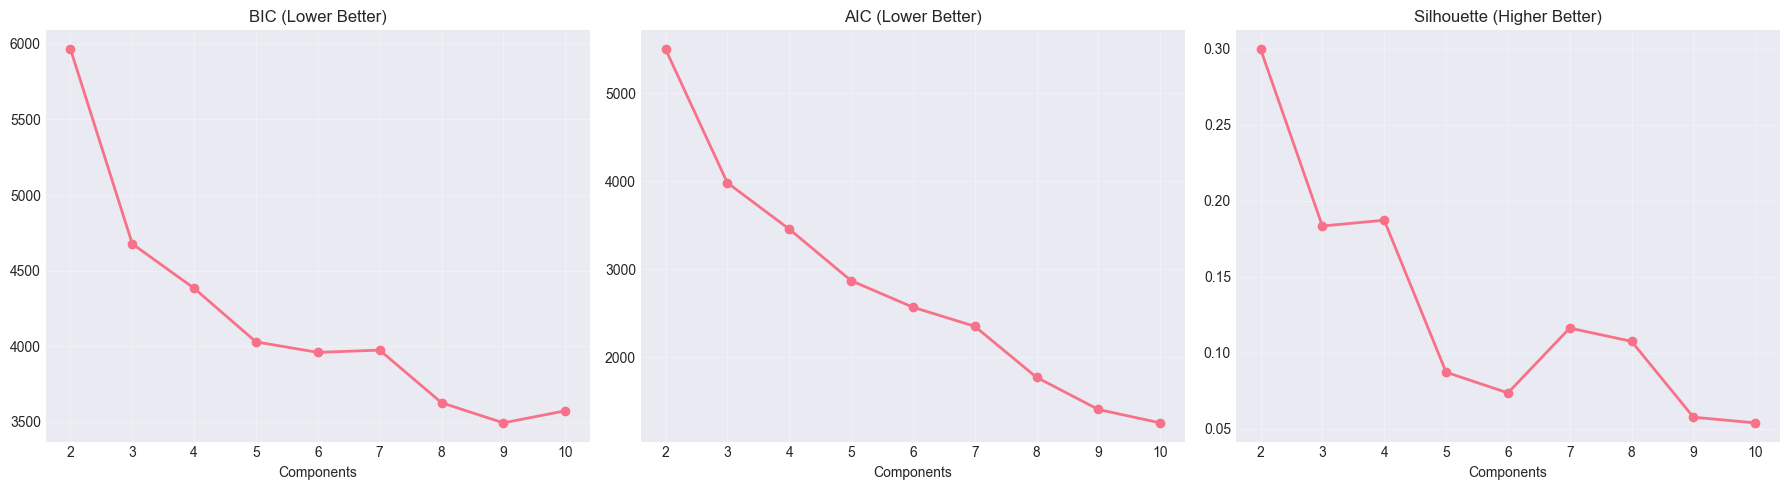

best_k_bic=9, best_k_aic=10, best_k_sil=2, chosen=9


In [5]:
k_values = range(2, 11)
bic_scores, aic_scores, sil_scores = [], [], []

for k in k_values:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k_bic = list(k_values)[int(np.argmin(bic_scores))]
best_k_aic = list(k_values)[int(np.argmin(aic_scores))]
best_k_sil = list(k_values)[int(np.argmax(sil_scores))]
optimal_k = best_k_bic

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(list(k_values), bic_scores, 'o-', linewidth=2); axes[0].set_title('BIC (Lower Better)')
axes[1].plot(list(k_values), aic_scores, 'o-', linewidth=2); axes[1].set_title('AIC (Lower Better)')
axes[2].plot(list(k_values), sil_scores, 'o-', linewidth=2); axes[2].set_title('Silhouette (Higher Better)')
for ax in axes: ax.set_xlabel('Components'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(GRAPH_DIR / '03D_01_component_selection.png', dpi=300, bbox_inches='tight'); plt.show()

print(f'best_k_bic={best_k_bic}, best_k_aic={best_k_aic}, best_k_sil={best_k_sil}, chosen={optimal_k}')

In [6]:
gmm_final = GaussianMixture(n_components=optimal_k, covariance_type='full', random_state=42)
gmm_final.fit(X_scaled)
labels = gmm_final.predict(X_scaled)
proba = gmm_final.predict_proba(X_scaled)
clustering_data['cluster'] = labels
clustering_data['cluster_confidence'] = proba.max(axis=1)

sil = silhouette_score(X_scaled, labels)
dbi = davies_bouldin_score(X_scaled, labels)
print(f'Silhouette={sil:.4f}, Davies-Bouldin={dbi:.4f}')

cluster_summary = clustering_data.groupby('cluster')[feature_cols + ['cluster_confidence']].mean().round(4)
display(cluster_summary)

cluster_summary.to_csv(DATA_DIR / '03D_cluster_feature_summary.csv')
clustering_data[['Name', 'cluster', 'cluster_confidence'] + feature_cols].to_csv(DATA_DIR / '03D_stock_cluster_assignments.csv', index=False)

Silhouette=0.0575, Davies-Bouldin=1.6113


,volatility,avg_return,avg_volume,volume_volatility,momentum,price_range,trend_strength,price_level,volume_to_price_ratio,cluster_confidence
cluster,,,,,,,,,,
0,0.0187,0.0000,9.436365e+06,0.3656,-0.0019,0.0336,0.3619,0.4160,2.914050e+05,0.9810
1,0.0161,-0.0043,4.977747e+06,0.3927,-0.0839,0.0264,0.0534,1.0187,7.795329e+04,0.9475
2,0.0327,-0.0162,3.924752e+07,0.3542,-0.2864,0.1246,0.2500,0.0289,2.462799e+07,1.0000
3,0.0168,0.0016,2.482174e+06,0.3698,0.0305,0.0287,0.3884,1.4490,2.891147e+04,0.9812
4,0.0179,0.0005,2.729800e+06,0.4238,0.0092,0.0321,0.1980,13.5086,2.509195e+03,1.0000
5,0.0272,-0.0036,7.381130e+07,0.3915,-0.0729,0.0305,0.1914,0.2217,4.114928e+06,1.0000
6,0.0157,-0.0018,1.945721e+06,0.3846,-0.0379,0.0263,0.2361,1.1379,2.478760e+04,0.9708
7,0.0308,0.0049,5.168116e+06,0.6694,0.0934,0.0342,0.3580,1.2770,1.004057e+05,0.9998
8,0.0224,-0.0062,5.344855e+06,0.4866,-0.1200,0.0408,0.2609,0.5640,2.169675e+05,0.9896


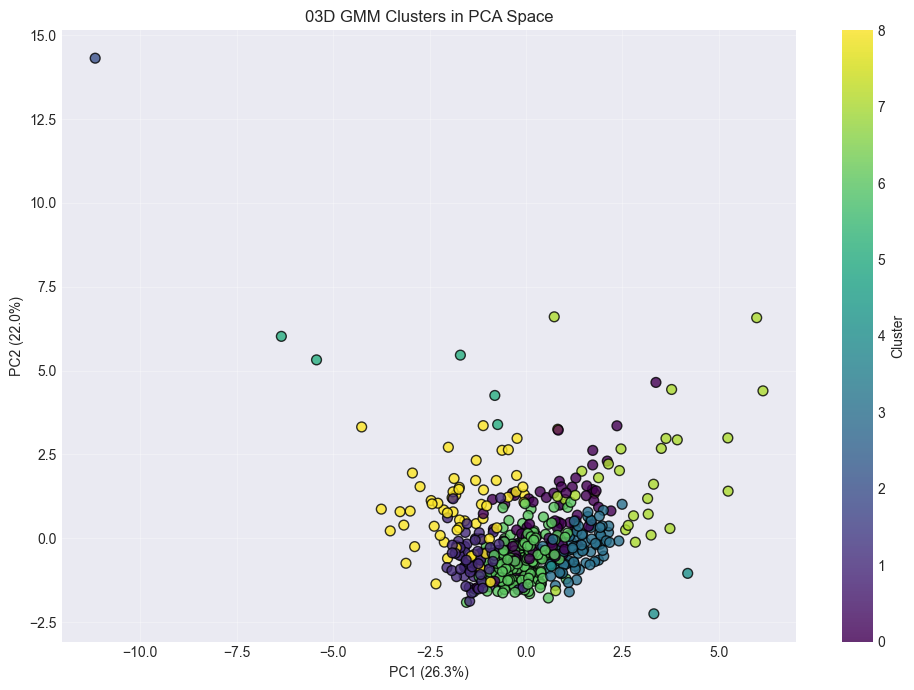

In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(X_pca[:,0], X_pca[:,1], c=clustering_data['cluster'], cmap='viridis', s=50, edgecolor='black', alpha=0.8)
ax.set_title('03D GMM Clusters in PCA Space')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})'); ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.grid(alpha=0.3); plt.colorbar(sc, label='Cluster')
plt.tight_layout(); plt.savefig(GRAPH_DIR / '03D_02_pca_scatter.png', dpi=300, bbox_inches='tight'); plt.show()

## Evaluation and Financial Interpretation
Use this section to assess statistical quality and practical finance meaning of clusters.

- Statistical checks: cluster concentration, feature differentiation profile.
- Finance checks: return-risk tradeoff, momentum dispersion, and liquidity context.
- Portfolio use: identify aggressive, defensive, and balanced baskets by regime.

=== Cluster Composition ===


,count,weight_pct
cluster,,
0,81,16.04
1,70,13.86
2,1,0.20
3,78,15.45
4,4,0.79
5,5,0.99
6,176,34.85
7,28,5.54
8,62,12.28


=== Cluster Feature Profile (mean) ===


,volatility,avg_return,avg_volume,volume_volatility,momentum,price_range,trend_strength,price_level,volume_to_price_ratio
cluster,,,,,,,,,
0,0.0187,0.0000,9.436365e+06,0.3656,-0.0019,0.0336,0.3619,0.4160,2.914050e+05
1,0.0161,-0.0043,4.977747e+06,0.3927,-0.0839,0.0264,0.0534,1.0187,7.795329e+04
2,0.0327,-0.0162,3.924752e+07,0.3542,-0.2864,0.1246,0.2500,0.0289,2.462799e+07
3,0.0168,0.0016,2.482174e+06,0.3698,0.0305,0.0287,0.3884,1.4490,2.891147e+04
4,0.0179,0.0005,2.729800e+06,0.4238,0.0092,0.0321,0.1980,13.5086,2.509195e+03
5,0.0272,-0.0036,7.381130e+07,0.3915,-0.0729,0.0305,0.1914,0.2217,4.114928e+06
6,0.0157,-0.0018,1.945721e+06,0.3846,-0.0379,0.0263,0.2361,1.1379,2.478760e+04
7,0.0308,0.0049,5.168116e+06,0.6694,0.0934,0.0342,0.3580,1.2770,1.004057e+05
8,0.0224,-0.0062,5.344855e+06,0.4866,-0.1200,0.0408,0.2609,0.5640,2.169675e+05


=== Risk-Return Lens ===


,avg_return,volatility,momentum,price_range,return_to_risk
cluster,,,,,
0,0.0000,0.0187,-0.0019,0.0336,0.0027
1,-0.0043,0.0161,-0.0839,0.0264,-0.2639
2,-0.0162,0.0327,-0.2864,0.1246,-0.4963
3,0.0016,0.0168,0.0305,0.0287,0.0973
4,0.0005,0.0179,0.0092,0.0321,0.0273
5,-0.0036,0.0272,-0.0729,0.0305,-0.1329
6,-0.0018,0.0157,-0.0379,0.0263,-0.1162
7,0.0049,0.0308,0.0934,0.0342,0.1581
8,-0.0062,0.0224,-0.1200,0.0408,-0.2751


[Insight] Cluster 7 has the strongest return-to-risk proxy in this snapshot.
[Insight] Cluster 6 is the most defensive regime by realized volatility.


C:\Users\25012923g\AppData\Local\Temp\ipykernel_11620\2623871987.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eval_df, x=cluster_col, y='momentum', ax=axes[1, 1], palette='Set2')


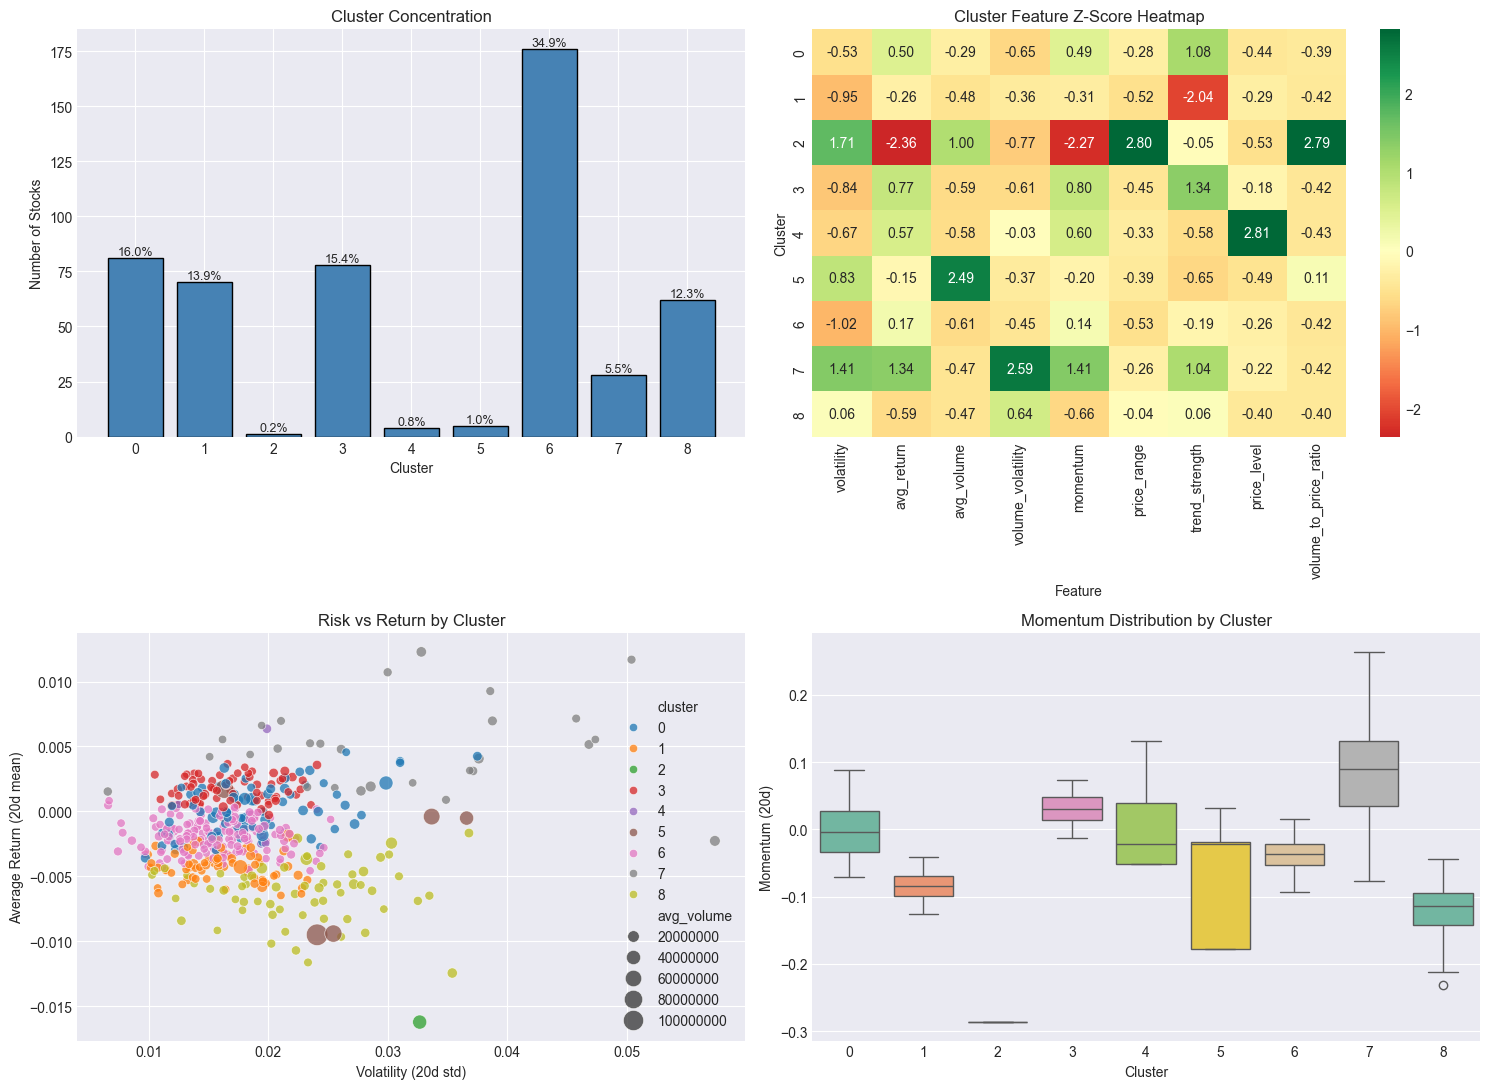

Saved evaluation dashboard: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\03_stock_clustering_analysis\graph\03D_03_evaluation_dashboard.png


In [8]:
method_tag = '03D'
cluster_col = 'cluster'
eval_df = clustering_data.copy()

size_tbl = eval_df[cluster_col].value_counts().sort_index().rename('count').to_frame()
size_tbl['weight_pct'] = 100 * size_tbl['count'] / size_tbl['count'].sum()

profile_mean = eval_df.groupby(cluster_col)[feature_cols].mean()
profile_std = profile_mean.std(ddof=0).replace(0, np.nan)
profile_z = ((profile_mean - profile_mean.mean()) / profile_std).fillna(0.0)

risk_cols = ['avg_return', 'volatility', 'momentum', 'price_range']
risk_view = profile_mean[risk_cols].copy()
risk_view['return_to_risk'] = risk_view['avg_return'] / risk_view['volatility'].replace(0, np.nan)

print('=== Cluster Composition ===')
display(size_tbl.round(2))

print('=== Cluster Feature Profile (mean) ===')
display(profile_mean.round(4))

print('=== Risk-Return Lens ===')
display(risk_view.round(4))

if len(risk_view) >= 2:
    best_rr = risk_view['return_to_risk'].idxmax()
    defensive = risk_view['volatility'].idxmin()
    print(f'[Insight] Cluster {best_rr} has the strongest return-to-risk proxy in this snapshot.')
    print(f'[Insight] Cluster {defensive} is the most defensive regime by realized volatility.')

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

bars = axes[0, 0].bar(size_tbl.index.astype(str), size_tbl['count'], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Cluster Concentration')
axes[0, 0].set_xlabel('Cluster'); axes[0, 0].set_ylabel('Number of Stocks')
for i, b in enumerate(bars):
    pct = size_tbl['weight_pct'].iloc[i]
    axes[0, 0].text(b.get_x() + b.get_width()/2, b.get_height(), f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

sns.heatmap(profile_z, cmap='RdYlGn', center=0, annot=True, fmt='.2f', ax=axes[0, 1])
axes[0, 1].set_title('Cluster Feature Z-Score Heatmap')
axes[0, 1].set_xlabel('Feature'); axes[0, 1].set_ylabel('Cluster')

sns.scatterplot(data=eval_df, x='volatility', y='avg_return', hue=cluster_col, size='avg_volume', sizes=(35, 240),
                alpha=0.75, palette='tab10', ax=axes[1, 0])
axes[1, 0].set_title('Risk vs Return by Cluster')
axes[1, 0].set_xlabel('Volatility (20d std)'); axes[1, 0].set_ylabel('Average Return (20d mean)')

sns.boxplot(data=eval_df, x=cluster_col, y='momentum', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Momentum Distribution by Cluster')
axes[1, 1].set_xlabel('Cluster'); axes[1, 1].set_ylabel('Momentum (20d)')

plt.tight_layout()
dashboard_path = GRAPH_DIR / f'{method_tag}_03_evaluation_dashboard.png'
plt.savefig(dashboard_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved evaluation dashboard: {dashboard_path}')